# 05 — SoilGrids uncertainty for the soil carbon stock

The headline stock (`02_carbon_pipeline.ipynb`) uses the SoilGrids `ocs` mean.
SoilGrids also publishes 5%, 50% and 95% quantiles of `ocs` 0–30 cm (Poggio et
al., 2021), but they are **not on Earth Engine**, so this notebook fetches them
from ISRIC's WCS for the district bounding box, samples them at every cell, and
propagates them to the district total.

**Why two bounds.** A district total needs the *correlation* of errors between
cells, which SoilGrids does not publish. Two limits bracket it:

| Bound | Assumption | Effect |
|---|---|---|
| Fully correlated | every cell is wrong in the same direction | Σ Q0.05 × area … Σ Q0.95 × area (widest) |
| Independent | cell errors cancel | normal approximation, sd per cell = (Q0.95 − Q0.05) / 3.29 (narrowest) |

SoilGrids errors come from covariates and model structure that vary smoothly
across a district, so the truth is much closer to the correlated bound. The
independent bound is shown to make clear how much a naive interval would
understate.

**Inputs.** `IIRS/Carbon_Stocks/soilgrids_quantiles/ocs_0-30cm_{Q0.05,Q0.5,Q0.95,mean}_igh.tif`,
on SoilGrids' native 250 m Interrupted Goode Homolosine grid. Requesting them
reprojected to lat/lon makes the server resample with nearest neighbour, which
alone drops agreement with the Earth Engine `ocs` from r ≈ 0.96 to 0.85, so the
native grid is kept and each cell is sampled in its own projection.
The first code cell downloads them if `maps.isric.org` is reachable; otherwise
download the four URLs it prints (any browser) into that folder and re-run.


In [1]:
import json
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))
import config as C
from pyproj import Transformer

QDIR = C.DATA / "soilgrids_quantiles"
QDIR.mkdir(exist_ok=True)
LAYERS = ["Q0.05", "Q0.5", "Q0.95", "mean"]
BBOX = (75.30, 30.50, 76.40, 31.10)          # lon/lat, covers both district boundaries
IGH = "+proj=igh +lat_0=0 +lon_0=0 +datum=WGS84 +units=m +no_defs"   # SoilGrids native CRS
to_igh = Transformer.from_crs("EPSG:4326", IGH, always_xy=True)
xs, ys = to_igh.transform([BBOX[0], BBOX[2], BBOX[0], BBOX[2]], [BBOX[1], BBOX[1], BBOX[3], BBOX[3]])
X0, X1, Y0, Y1 = min(xs) - 1000, max(xs) + 1000, min(ys) - 1000, max(ys) + 1000
WCS = ("https://maps.isric.org/mapserv?map=/map/ocs.map&SERVICE=WCS&VERSION=2.0.1&REQUEST=GetCoverage"
       "&COVERAGEID=ocs_0-30cm_{q}&FORMAT=GEOTIFF_INT16"
       f"&SUBSET=X({X0:.0f},{X1:.0f})&SUBSET=Y({Y0:.0f},{Y1:.0f})")
tif = lambda q: QDIR / f"ocs_0-30cm_{q}_igh.tif"


In [2]:
import urllib.request

def fetch(q):
    out = tif(q)
    if out.exists() and out.stat().st_size > 1000:
        return "present"
    try:
        with urllib.request.urlopen(WCS.format(q=q), timeout=120) as r:
            data = r.read()
        if not data.startswith((b"II*", b"MM\x00*")):
            return "not a GeoTIFF: " + data[:120].decode(errors="replace")
        out.write_bytes(data)
        return f"downloaded {len(data):,} bytes"
    except Exception as e:
        return f"failed: {e}"

status = {q: fetch(q) for q in LAYERS}
for q, s in status.items():
    print(f"{q:6s} {s}")
missing = [q for q in LAYERS if not tif(q).exists()]
if missing:
    print("\nDownload these into", QDIR, "and re-run:")
    for q in missing:
        print(" ", WCS.format(q=q))
    raise SystemExit("SoilGrids quantile layers not available yet")


Q0.05  present
Q0.5   present
Q0.95  present
mean   present


## Sample every cell

Each cell's value is the mean of a 5 × 5 set of points spread over the cell,
projected to Homolosine, which matches the Earth Engine reduction (mean of the
SoilGrids pixels in the cell). Mapped units of `ocs` are t/ha. The served
GeoTIFF carries no CRS tag; its transform is in Homolosine metres. That is checked, not assumed: the WCS
mean must reproduce the Earth Engine `ocs` already in the v2 table.


In [3]:
import rasterio

cells = pd.read_csv(C.DATA / "v2" / "ludhiana_cells_v2.csv.gz",
                    usecols=["cell_id", "grid_row", "grid_col", "cell_area_ha", "in_district_frac",
                             f"in_{C.BOUNDARY_CHECK}", "soil_valid_frac", "ocs_030_t_ha"])
step = C.GRID_STEP_DEG
lon0, lat0 = cells["grid_col"].to_numpy() * step, cells["grid_row"].to_numpy() * step
OFFS = np.linspace(0.1, 0.9, 5)

for q in LAYERS:
    with rasterio.open(tif(q)) as src:
        A, T = src.read(1).astype(float), src.transform
    if abs(T.a - 250) > 5:
        raise ValueError(f"{q}: expected the native ~250 m Homolosine grid, got pixel size {T.a}")
    acc, n = np.zeros(len(cells)), np.zeros(len(cells))
    for i in OFFS:
        for j in OFFS:
            X, Y = to_igh.transform(lon0 + i * step, lat0 + j * step)
            c, r = ((X - T.c) / T.a).astype(int), ((Y - T.f) / T.e).astype(int)
            inside = (r >= 0) & (r < A.shape[0]) & (c >= 0) & (c < A.shape[1])
            v = np.full(len(cells), np.nan)
            v[inside] = A[r[inside], c[inside]]
            v[v <= 0] = np.nan                              # -32768 and 0 = no data
            acc += np.nan_to_num(v); n += ~np.isnan(v)
    cells[f"wcs_{q}"] = np.where(n > 0, acc / np.maximum(n, 1), np.nan)

ok = cells["soil_valid_frac"].ge(0.999) & cells["wcs_mean"].notna() & cells["ocs_030_t_ha"].notna()
r = cells.loc[ok, "wcs_mean"].corr(cells.loc[ok, "ocs_030_t_ha"])
ratio = float((cells.loc[ok, "wcs_mean"] / cells.loc[ok, "ocs_030_t_ha"]).median())
print(f"WCS mean vs Earth Engine ocs: r = {r:.3f}, median ratio = {ratio:.3f}  (n = {ok.sum():,})")
assert r > 0.9 and abs(ratio - 1) < 0.05, "WCS layer does not match the Earth Engine ocs: check units or georeferencing"
assert (cells.loc[ok, "wcs_Q0.05"] <= cells.loc[ok, "wcs_Q0.95"]).all()


WCS mean vs Earth Engine ocs: r = 0.960, median ratio = 1.000  (n = 62,244)


## Propagate to the district total

In [4]:
Z90 = 3.29                                   # width of a central 90% normal interval, in sd

def totals(area_in):
    a = area_in * cells["soil_valid_frac"]
    use = cells["wcs_mean"].notna() & cells["ocs_030_t_ha"].notna()
    a = a.where(use, 0)
    headline = float((cells["ocs_030_t_ha"] * a).sum())
    q05, q50, q95 = (float((cells[f"wcs_{q}"] * a).sum()) for q in ["Q0.05", "Q0.5", "Q0.95"])
    sd = (cells["wcs_Q0.95"] - cells["wcs_Q0.05"]) / Z90
    sd_ind = float(np.sqrt(((sd * a) ** 2).sum()))
    to_m = lambda t: round(t / 1e6, 3)
    return {
        "headline_mean_mtc": to_m(headline),
        "median_q50_mtc": to_m(q50),
        "correlated_90pct_mtc": [to_m(q05), to_m(q95)],
        "independent_90pct_mtc": [to_m(headline - 1.645 * sd_ind), to_m(headline + 1.645 * sd_ind)],
        "soil_area_ha": round(float(a.sum())),
    }

area = cells["cell_area_ha"]
out = {
    "source": "ISRIC SoilGrids 2.0 ocs 0-30cm Q0.05/Q0.5/Q0.95/mean, WCS maps.isric.org, native Homolosine 250 m, 5x5 within-cell mean",
    "units_check": {"r_vs_earth_engine_ocs": round(r, 3), "median_ratio": round(ratio, 3)},
    "median_cell_quantiles_t_ha": {q: round(float(cells.loc[ok, f"wcs_{q}"].median()), 1) for q in LAYERS},
    "median_cell_relative_90pct_width": round(float(((cells["wcs_Q0.95"] - cells["wcs_Q0.05"]) / cells["wcs_mean"])[ok].median()), 3),
    C.BOUNDARY_DEFAULT: totals(area * cells["in_district_frac"]),
    C.BOUNDARY_CHECK: totals(area * cells[f"in_{C.BOUNDARY_CHECK}"]),
    "reading": ("SoilGrids does not publish error correlation. The correlated interval is the honest one to quote; "
                "the independent interval shows how far a naive sum would understate uncertainty."),
}
print(json.dumps(out, indent=2))
(C.RESULTS / "soilgrids_uncertainty.json").write_text(json.dumps(out, indent=2))
print("Wrote results/soilgrids_uncertainty.json; re-run 02_carbon_pipeline.ipynb to add it to the summary.")


{
  "source": "ISRIC SoilGrids 2.0 ocs 0-30cm Q0.05/Q0.5/Q0.95/mean, WCS maps.isric.org, native Homolosine 250 m, 5x5 within-cell mean",
  "units_check": {
    "r_vs_earth_engine_ocs": 0.96,
    "median_ratio": 1.0
  },
  "median_cell_quantiles_t_ha": {
    "Q0.05": 7.0,
    "Q0.5": 24.0,
    "Q0.95": 82.0,
    "mean": 31.0
  },
  "median_cell_relative_90pct_width": 2.418,
  "ludhiana_geoboundaries_adm2": {
    "headline_mean_mtc": 10.507,
    "median_q50_mtc": 8.205,
    "correlated_90pct_mtc": [
      2.173,
      27.685
    ],
    "independent_90pct_mtc": [
      10.457,
      10.558
    ],
    "soil_area_ha": 341413
  },
  "ludhiana_census2011_datameet": {
    "headline_mean_mtc": 10.154,
    "median_q50_mtc": 7.942,
    "correlated_90pct_mtc": [
      2.099,
      26.714
    ],
    "independent_90pct_mtc": [
      10.105,
      10.204
    ],
    "soil_area_ha": 330077
  },
  "reading": "SoilGrids does not publish error correlation. The correlated interval is the honest one to quot

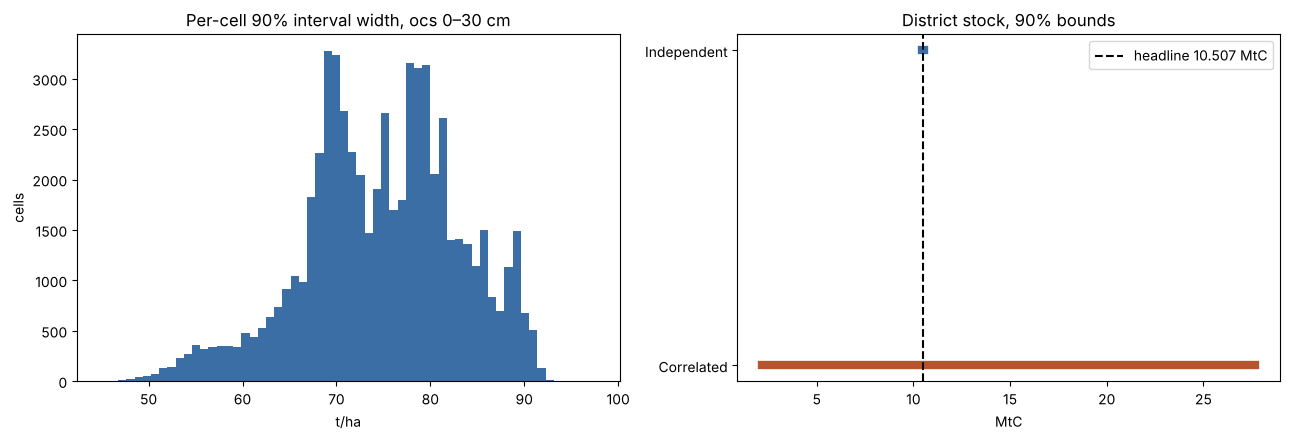

In [5]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))
w = (cells["wcs_Q0.95"] - cells["wcs_Q0.05"])[ok]
ax[0].hist(w, bins=60, color="#3b6ea5")
ax[0].set(title="Per-cell 90% interval width, ocs 0–30 cm", xlabel="t/ha", ylabel="cells")
d = out[C.BOUNDARY_DEFAULT]
labels = ["Correlated", "Independent"]
for i, k in enumerate(["correlated_90pct_mtc", "independent_90pct_mtc"]):
    lo, hi = d[k]
    ax[1].plot([lo, hi], [i, i], lw=6, color=["#b5542d", "#3b6ea5"][i])
ax[1].axvline(d["headline_mean_mtc"], color="k", ls="--", label=f"headline {d['headline_mean_mtc']} MtC")
ax[1].set(yticks=[0, 1], yticklabels=labels, xlabel="MtC", title="District stock, 90% bounds")
ax[1].legend(); plt.tight_layout(); plt.savefig(C.RESULTS / "fig_soilgrids_uncertainty.png", dpi=130); plt.show()
